# CMAPSS FD001 — Exploratory Data Analysis

This notebook establishes the empirical foundation for everything that follows. Before engineering features or training a model, we need honest answers to three questions: **What does the raw sensor data look like?** **Which sensors carry predictive information about degradation?** **What does the RUL label distribution look like, and does the 125-cycle cap make sense?**

The NASA CMAPSS FD001 dataset contains 100 turbofan engines each run to failure under a single operating condition with a single fault mode — High-Pressure Compressor (HPC) degradation. Every cycle, 21 sensor channels and 3 operating setting channels are recorded. The training set provides the full run-to-failure sequence for each engine; the test set provides a truncated sequence and the true RUL at the final observed cycle.

Work through this notebook sequentially. The variance analysis in §3 directly determines which sensors get dropped in `src/features.py`; the degradation trajectory plots in §5 give visual intuition for *why* a rolling window feature captures the signal better than a raw reading.

---

**Before running:** place the following files in `data/raw/` (space-separated, no header):
- `train_FD001.txt`
- `test_FD001.txt`
- `RUL_FD001.txt`

Sources: [NASA PCOE](https://www.nasa.gov/intelligent-systems-division/discovery-and-systems-health/pcoe/pcoe-data-set-repository/) or the [Kaggle mirror](https://www.kaggle.com/datasets/behrad3d/nasa-cmaps).

**Environment:** `conda activate cmapss-rul` (from project root), then open this notebook with the `cmapss-rul` kernel.

In [18]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Project root (works whether cwd is repo root or notebooks/)
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

RAW = ROOT / "data" / "raw"
sys.path.insert(0, str(ROOT))

from src.features import COLUMNS, CONSTANT_SENSORS, load_raw, add_rul
from src.utils import plot_degradation_trajectories, plot_rul_distribution

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

print("ROOT:", ROOT)
print("RAW:", RAW)

ROOT: /Users/alvinalias/Library/Mobile Documents/com~apple~CloudDocs/Documents/Data Science/Resume/Portfolio Build/active/cmapss_rul
RAW: /Users/alvinalias/Library/Mobile Documents/com~apple~CloudDocs/Documents/Data Science/Resume/Portfolio Build/active/cmapss_rul/data/raw


## 1. Load the Raw Data

The raw `.txt` files have no column headers — we assign them manually in `load_raw()`. The 26 columns are: `unit` (engine ID), `cycle` (time step), three operating settings, and 21 sensor channels. `add_rul()` computes the RUL label for each row as `(max_cycle_for_that_engine − current_cycle)`, then clips at 125.

Inspect the head output below. Notice that `op_setting_3` is always 100.0 — FD001 has a single operating condition — and that several sensor columns appear visually constant. We'll confirm that quantitatively in §3.

In [19]:
required = ["train_FD001.txt", "test_FD001.txt", "RUL_FD001.txt"]
missing = [f for f in required if not (RAW / f).exists()]
if missing:
    raise FileNotFoundError(
        f"Missing in {RAW}: {missing}. Download FD001 from NASA PCOE or Kaggle and copy files here."
    )
print("All FD001 raw files present.")

All FD001 raw files present.


In [20]:
train_path = RAW / "train_FD001.txt"
train = load_raw(train_path)
train_labeled = add_rul(train.copy())

print(train.shape)
print("Engines:", train["unit"].nunique())
display(train.head())

(20631, 26)
Engines: 100


,unit,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## 2. Engine Lifetime Distribution

The histogram below shows how many cycles each of the 100 training engines ran before failure. This distribution has two important implications. First, the standard deviation (~46 cycles) is your naive RMSE floor — a model that always predicts the mean would score about 46 on the test set. Second, the long right tail (engines surviving 300+ cycles) means the model needs to handle both very short and very long remaining lives without collapsing to the center.

The piecewise-linear RUL label clips all values above 125, so engines in the early phase of a 300-cycle run are labelled identically to engines at cycle 50 of a 128-cycle run. That's intentional: the model should focus its capacity on late-stage degradation, not on distinguishing healthy-from-healthy.

,min,max,count,life
count,100.0,100.000000,100.000000,100.000000
mean,1.0,206.310000,206.310000,206.310000
std,0.0,46.342749,46.342749,46.342749
min,1.0,128.000000,128.000000,128.000000
25%,1.0,177.000000,177.000000,177.000000
50%,1.0,199.000000,199.000000,199.000000
75%,1.0,229.250000,229.250000,229.250000
max,1.0,362.000000,362.000000,362.000000


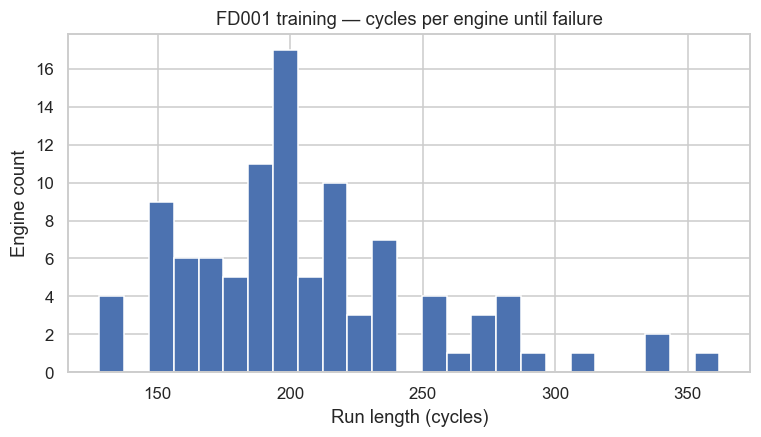

In [21]:
cycles = train.groupby("unit")["cycle"].agg(["min", "max", "count"])
cycles["life"] = cycles["max"] - cycles["min"] + 1
display(cycles.describe())

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(cycles["life"], bins=25, edgecolor="white")
ax.set_xlabel("Run length (cycles)")
ax.set_ylabel("Engine count")
ax.set_title("FD001 training — cycles per engine until failure")
plt.show()

## 3. Sensor Variance Analysis — Which Channels Are Informative?

Not all 21 sensors are useful. Some channels were included in the CMAPSS simulation for physical completeness but vary so little across the dataset that they provide no discriminative signal for RUL prediction. The variance table below ranks sensors from lowest to highest variance.

The key decision point: sensors with variance below ~1e-6 are effectively constant. The cell also prints the `CONSTANT_SENSORS` list already hardcoded in `src/features.py` — verify it matches. Any mismatch here would mean the feature pipeline drops the wrong sensors, silently corrupting every downstream result.

In [ ]:
sensor_cols = [c for c in train.columns if c.startswith("sensor_")]
variances = train[sensor_cols].var()
variances_sorted = variances.sort_values()
display(variances_sorted.to_frame("variance"))

near_constant = variances_sorted[variances_sorted < 1e-6].index.tolist()
print("Near-zero variance sensors:", near_constant)
print("Project CONSTANT_SENSORS list:", CONSTANT_SENSORS)

## 4. Sensor Correlation Structure

Before committing to a tree-based model, it's worth understanding whether the informative sensors are redundant with each other. The heatmap below shows pairwise Pearson correlations across a stratified subsample of training rows (sampling within each engine to avoid biasing toward long-lived engines).

Highly correlated sensor clusters tell us that the model may assign importance somewhat arbitrarily between correlated features — a known XGBoost behavior. SHAP's TreeExplainer handles this more gracefully than raw feature importance, which is one reason SHAP is the interpretability tool of choice here rather than `model.feature_importances_`.

In [ ]:
# Correlation among sensors (subsample per engine for speed)
parts = []
for _, g in train.groupby("unit"):
    step = max(1, len(g) // 50)
    parts.append(g.iloc[::step])
sample = pd.concat(parts, ignore_index=True)
corr = sample[sensor_cols].corr()
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, cmap="vlag", center=0, ax=ax, square=False)
ax.set_title("Sensor correlation (subsampled train rows)")
plt.tight_layout()
plt.show()

## 5. RUL Label Distribution

The histogram below shows the distribution of clipped RUL values across all training rows. The spike at 125 represents all the early-life cycles that have been capped — every engine contributes many rows labelled 125. The remainder of the distribution slopes downward toward 0, reflecting the natural accumulation of late-stage degradation cycles.

For model evaluation, we care most about accuracy in the 0–50 cycle range, where prediction errors have real operational consequences. The asymmetric scoring functions used in the CMAPSS literature (e.g., the exponential penalty from Saxena et al. 2010) penalise *late* predictions — predicting 40 cycles remaining when only 10 remain — more heavily than *early* predictions. RMSE treats both symmetrically; keep that in mind when comparing to published results.

In [ ]:
plot_rul_distribution(train_labeled)
plt.show()

## 6. Degradation Trajectories — The Physical Story

This is the most important plot in the EDA. Each line is one engine's sensor reading plotted over its full lifecycle. What you are looking for: **a consistent directional trend**, ideally visible across most engines, that distinguishes a degrading engine from a healthy one.

Sensors with clear monotonic trends (rising or falling as the engine approaches failure) are strong RUL predictors. Sensors with flat or random-walk trajectories will contribute noise. Compare these trajectories to your variance rankings from §3 — the high-variance sensors should show the clearest trends here.

Also notice the cycle-to-cycle noise within each trajectory. This is exactly the noise that the 30-cycle rolling mean in `build_features()` is designed to filter. A raw sensor reading at cycle *t* is less predictive than the average over cycles *t−29* through *t*.

In [ ]:
# Example degradation trajectories — pick sensors with visible variance
active_sensors = [s for s in sensor_cols if s not in CONSTANT_SENSORS][:4]
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.ravel()
for ax, sensor in zip(axes, active_sensors):
    plot_degradation_trajectories(train, sensor, n_units=12, ax=ax)
plt.tight_layout()
plt.show()

## What We Learned — and What It Means for Modeling

This EDA surfaces four facts that directly shape every modeling decision downstream.

**Seven sensors carry no predictive signal.** The variance analysis confirms that `sensor_1`, `sensor_5`, `sensor_6`, `sensor_10`, `sensor_16`, `sensor_18`, and `sensor_19` are effectively constant across all 100 engines throughout their full run-to-failure lifetimes. Keeping them would add noise and dimension without adding information. `src/features.py` drops them before any feature engineering runs.

**Engine lifetimes vary significantly, and that variation is real signal.** Run lengths range from 128 to 362 cycles with a median around 200. This spread is not noise — it reflects genuine variation in operating stress and component tolerance. A model that ignores cycle position entirely (predicting a fixed mean) would have RMSE close to the standard deviation of run lengths, roughly 46 cycles. Any useful model must beat that.

**The RUL cap at 125 cycles is justified by the data.** The RUL distribution plot shows a sharp cliff at 125 — the piecewise-linear label convention used throughout the CMAPSS literature. Without this cap, the loss function is dominated by the plateau region where all early-life engines look identical, and the model learns nothing about late-stage degradation. With the cap, every training example is informative.

**Degradation is a trend, not a point.** The trajectory plots show that individual sensor readings are noisy cycle-to-cycle, but the *direction* of change over ~30 cycles is clearly visible in the sensors with real variance. This is the physical justification for rolling mean and rolling standard deviation features: we want to tell the model about the trend, not the noise. The choice of a 30-cycle window in `src/features.py` reflects the typical scale over which HPC fouling becomes visible in the sensor record.

---

### Next: `02_feature_engineering.ipynb`

Build the rolling features defined in `src/features.py` (`build_features()`), verify that the engineered feature distributions look sensible, confirm alignment with the API's `readings_to_dataframe()` logic, and export the processed training and test sets for modeling.